# LAB 2 — Đặc trưng tiếng nói và nhận dạng bằng MFCC + DTW

Notebook triển khai tuần tự các phần thực hành **A → G**:

- A. Thu dữ liệu và kiểm tra chất lượng
- B. Đặc trưng miền thời gian: Energy/RMS/ZCR
- C. Endpoint detection
- D. MFCC
- E. DTW tự cài đặt
- F. Bộ nhận dạng nearest-template
- G. Đánh giá và thí nghiệm

Baseline:
- Fs = 16 kHz
- Frame = 25 ms
- Hop = 10 ms
- Hamming window
- Pre-emphasis α = 0.97
- NFFT = 512
- 24 Mel filters
- 13 MFCC
- Local distance = Euclidean
- DTW cost chuẩn hóa theo độ dài optimal path

## Dataset đang sử dụng

Dataset của bạn gồm **5 lớp**, mỗi lớp **5 file âm thanh**:

```text
data/
├── down/
│   ├── *.wav   (5 file)
├── go/
│   ├── *.wav   (5 file)
├── left/
│   ├── *.wav   (5 file)
├── right/
│   ├── *.wav   (5 file)
└── up/
    ├── *.wav   (5 file)
```

Notebook dùng:
- **3 file đầu mỗi lớp** làm template/train.
- **2 file còn lại mỗi lớp** làm test.

Như vậy:
- Train/template: 5 × 3 = **15 file**
- Test: 5 × 2 = **10 file**
- Tổng: **25 file**

In [1]:
# Nếu thiếu thư viện, bỏ dấu # ở dòng dưới rồi chạy một lần:
# %pip install numpy scipy matplotlib librosa soundfile scikit-learn pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

from pathlib import Path
from scipy.signal import lfilter
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

print("NumPy:", np.__version__)
print("Librosa:", librosa.__version__)

NumPy: 2.2.6
Librosa: 0.11.0


## 0. Cấu hình chung

In [2]:
FS = 16000
FRAME_MS = 25
HOP_MS = 10

WIN = int(round(FS * FRAME_MS / 1000))   # 400 mẫu
HOP = int(round(FS * HOP_MS / 1000))    # 160 mẫu
NFFT = 512
N_MELS = 24
N_MFCC = 13
PRE_EMPH = 0.97

# 5 lớp đúng theo dataset của bạn
LABELS = ["down", "go", "left", "right", "up"]

# Tên hiển thị trên confusion matrix
DISPLAY_LABELS = {
    "down": "down",
    "go": "go",
    "left": "left",
    "right": "right",
    "up": "up"
}

# Notebook và thư mục data nên đặt cùng một thư mục.
# Nếu data nằm nơi khác, chỉ cần sửa dòng này.
DATASET_ROOT = Path("data")

FIG_DIR = Path("figures")
TRIM_DIR = Path("trimmed")
RESULT_DIR = Path("results")

# Tự tạo các thư mục output khi clone project về máy mới
FIG_DIR.mkdir(parents=True, exist_ok=True)
TRIM_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_ROOT =", DATASET_ROOT.resolve())
print("WIN =", WIN, "samples")
print("HOP =", HOP, "samples")
print("LABELS =", LABELS)

DATASET_ROOT = C:\xulyamthanh\lab02_2351260688_NguyenNgocTien\data
WIN = 400 samples
HOP = 160 samples
LABELS = ['down', 'go', 'left', 'right', 'up']


## Hàm đọc âm thanh và framing

In [3]:
def load_audio(path, normalize=True):
    # Đọc audio, chuyển mono và resample về 16 kHz.
    y, sr = librosa.load(path, sr=FS, mono=True)
    y = y.astype(np.float32)

    if normalize:
        peak = np.max(np.abs(y)) if len(y) else 0.0
        if peak > 0:
            y = y / (peak + 1e-12)

    return y


def frame_signal(y, win=WIN, hop=HOP, apply_hamming=True):
    # Chia tín hiệu thành các frame. Output: (n_frames, win)
    if len(y) < win:
        y = np.pad(y, (0, win - len(y)))

    n_frames = 1 + int(np.floor((len(y) - win) / hop))
    frames = np.zeros((n_frames, win), dtype=np.float32)

    window = np.hamming(win).astype(np.float32) if apply_hamming else np.ones(win, dtype=np.float32)

    for r in range(n_frames):
        start = r * hop
        frames[r] = y[start:start + win] * window

    return frames


def frame_times(n_frames, hop=HOP, fs=FS):
    return np.arange(n_frames) * hop / fs

# A. Thu dữ liệu và kiểm tra chất lượng

Yêu cầu:
- Vocabulary 5–10 từ, mỗi từ ≥ 5 lần lặp.
- WAV mono 16 kHz.
- Vẽ waveform ít nhất 3 từ.
- Kiểm tra clipping và silence đầu/cuối.
- Train/test phải tách riêng.

In [4]:
def list_dataset(root=DATASET_ROOT, labels=LABELS):
    rows = []

    for lab in labels:
        folder = Path(root) / lab

        if not folder.exists():
            print(f"[THIẾU THƯ MỤC] {folder}")
            continue

        files = sorted(folder.glob("*.wav"))

        for f in files:
            y, sr = librosa.load(f, sr=None, mono=False)

            if y.ndim == 1:
                channels = 1
                peak = float(np.max(np.abs(y))) if len(y) else 0.0
                duration = len(y) / sr
            else:
                channels = y.shape[0]
                peak = float(np.max(np.abs(y))) if y.size else 0.0
                duration = y.shape[-1] / sr

            rows.append({
                "label": lab,
                "file": str(f),
                "sr_goc": sr,
                "channels": channels,
                "duration_s": duration,
                "peak_abs": peak,
                "possible_clipping": peak >= 0.999
            })

    return pd.DataFrame(rows)


dataset_info = list_dataset()

if len(dataset_info):
    display(dataset_info)

    print("\nSố file theo lớp:")
    counts = dataset_info.groupby("label").size().reindex(LABELS, fill_value=0)
    display(counts.rename("count").to_frame())

    print("\nKiểm tra yêu cầu 5 file/lớp:")
    all_ok = True
    for lab in LABELS:
        n = int(counts.loc[lab])
        status = "OK" if n == 5 else "CHƯA ĐÚNG"
        print(f"{lab:6s}: {n} file -> {status}")
        if n != 5:
            all_ok = False

    if all_ok:
        print("\nDataset hợp lệ: 5 lớp × 5 file = 25 file.")
    else:
        print("\nHãy đảm bảo mỗi thư mục có đúng 5 file .wav trước khi chạy các phần tiếp theo.")

    print("\nFile có khả năng clipping:")
    clipping = dataset_info[dataset_info["possible_clipping"]]
    display(clipping if len(clipping) else pd.DataFrame({"Thông báo": ["Không phát hiện clipping rõ ràng"]}))
else:
    print("Không tìm thấy file WAV.")
    print("Hãy kiểm tra cấu trúc: data/down, data/go, data/left, data/right, data/up")

c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,label,file,sr_goc,channels,duration_s,peak_abs,possible_clipping
0,down,data\down\down_01.wav,16000,1,1.0,0.734039,False
1,down,data\down\down_02.wav,16000,1,1.0,0.871887,False
2,down,data\down\down_03.wav,16000,1,1.0,0.672333,False
3,down,data\down\down_04.wav,16000,1,1.0,0.849274,False
4,down,data\down\down_05.wav,16000,1,1.0,0.724243,False
5,go,data\go\go_01.wav,16000,1,1.0,0.756744,False
6,go,data\go\go_02.wav,16000,1,1.0,0.372559,False
7,go,data\go\go_03.wav,16000,1,1.0,0.744781,False
8,go,data\go\go_04.wav,16000,1,1.0,0.872345,False
9,go,data\go\go_05.wav,16000,1,1.0,0.789551,False



Số file theo lớp:


,count
label,
down,5
go,5
left,5
right,5
up,5



Kiểm tra yêu cầu 5 file/lớp:
down  : 5 file -> OK
go    : 5 file -> OK
left  : 5 file -> OK
right : 5 file -> OK
up    : 5 file -> OK

Dataset hợp lệ: 5 lớp × 5 file = 25 file.

File có khả năng clipping:


,label,file,sr_goc,channels,duration_s,peak_abs,possible_clipping
16,right,data\right\right_02.wav,16000,1,1.0,1.000000,True
23,up,data\up\up_04.wav,16000,1,1.0,0.999969,True


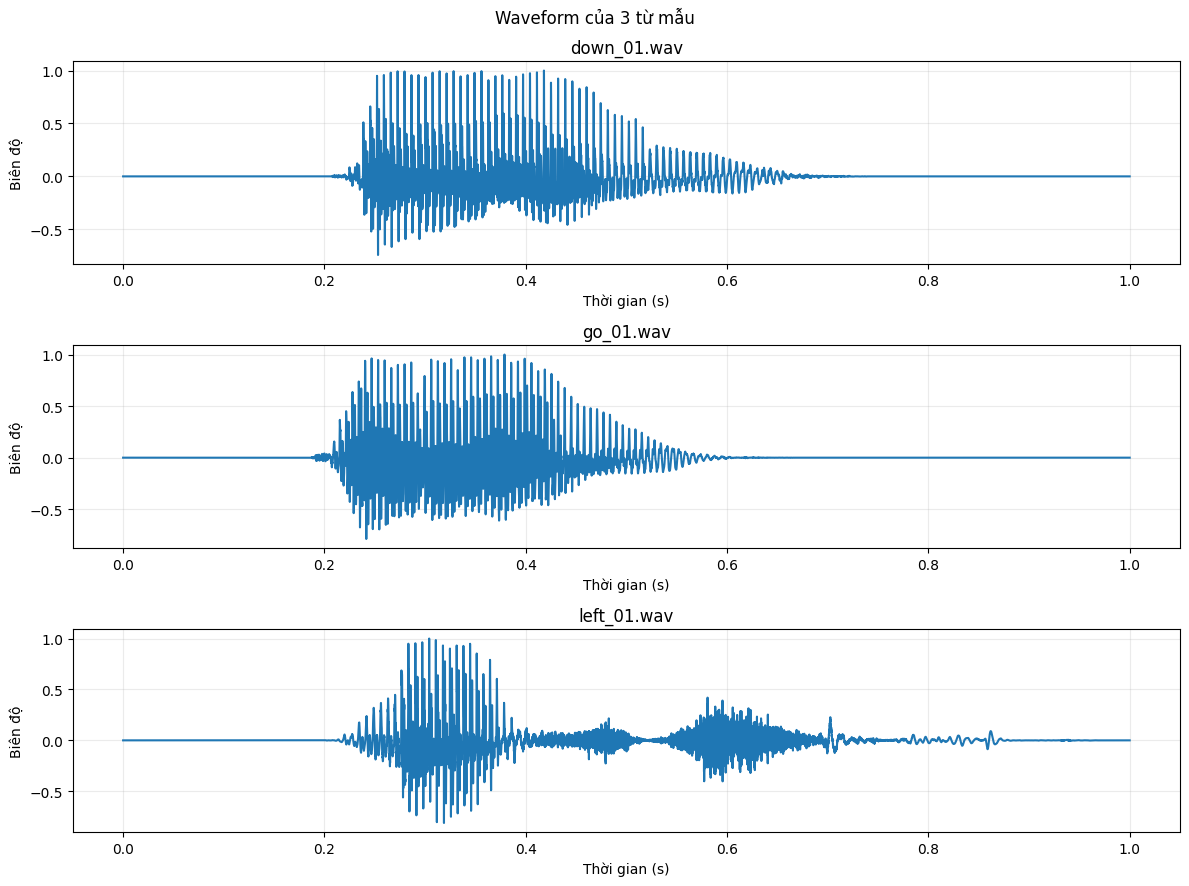

In [5]:
def plot_waveforms(files, title="Waveform"):
    n = len(files)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3*n), squeeze=False)

    for ax, f in zip(axes[:, 0], files):
        y = load_audio(f)
        t = np.arange(len(y)) / FS
        ax.plot(t, y)
        ax.set_title(Path(f).name)
        ax.set_xlabel("Thời gian (s)")
        ax.set_ylabel("Biên độ")
        ax.grid(alpha=0.25)

    fig.suptitle(title)
    plt.tight_layout()
    return fig


example_files = []
for lab in LABELS[:3]:
    fs = sorted((DATASET_ROOT / lab).glob("*.wav"))
    if fs:
        example_files.append(fs[0])

if example_files:
    fig = plot_waveforms(example_files, "Waveform của 3 từ mẫu")
    fig.savefig(FIG_DIR / "A_waveforms_3_words.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Chưa đủ dữ liệu để vẽ waveform.")

## Chia train/test trước khi tạo template

In [6]:
def split_files(root=DATASET_ROOT, labels=LABELS, n_train=3):
    train_files = {}
    test_files = {}

    for lab in labels:
        files = sorted((Path(root) / lab).glob("*.wav"))

        if len(files) < 5:
            print(f"[CẢNH BÁO] Lớp '{lab}' chỉ có {len(files)} file, yêu cầu hiện tại là 5.")

        train_files[lab] = files[:n_train]
        test_files[lab] = files[n_train:]

    return train_files, test_files


TRAIN_FILES, TEST_FILES = split_files(n_train=3)

print("Phân chia dữ liệu:")
for lab in LABELS:
    print(
        f"{lab:6s}: "
        f"train={len(TRAIN_FILES[lab])} file | "
        f"test={len(TEST_FILES[lab])} file"
    )

print("\nTổng train =", sum(len(v) for v in TRAIN_FILES.values()))
print("Tổng test  =", sum(len(v) for v in TEST_FILES.values()))

Phân chia dữ liệu:
down  : train=3 file | test=2 file
go    : train=3 file | test=2 file
left  : train=3 file | test=2 file
right : train=3 file | test=2 file
up    : train=3 file | test=2 file

Tổng train = 15
Tổng test  = 10


### Phân chia cho dataset 25 file

Vì mỗi lớp chỉ có 5 mẫu, notebook giữ đúng cách chia baseline của Lab:

- 3 mẫu/lớp làm **template train**
- 2 mẫu/lớp làm **test**
- Không có file nào đồng thời nằm trong train và test

Điều này tránh **data leakage** khi đánh giá DTW.

# B. Đặc trưng miền thời gian

Tính:
- Short-time Energy
- RMS
- Zero-Crossing Rate (ZCR)

Và vẽ trên cùng trục thời gian với waveform.

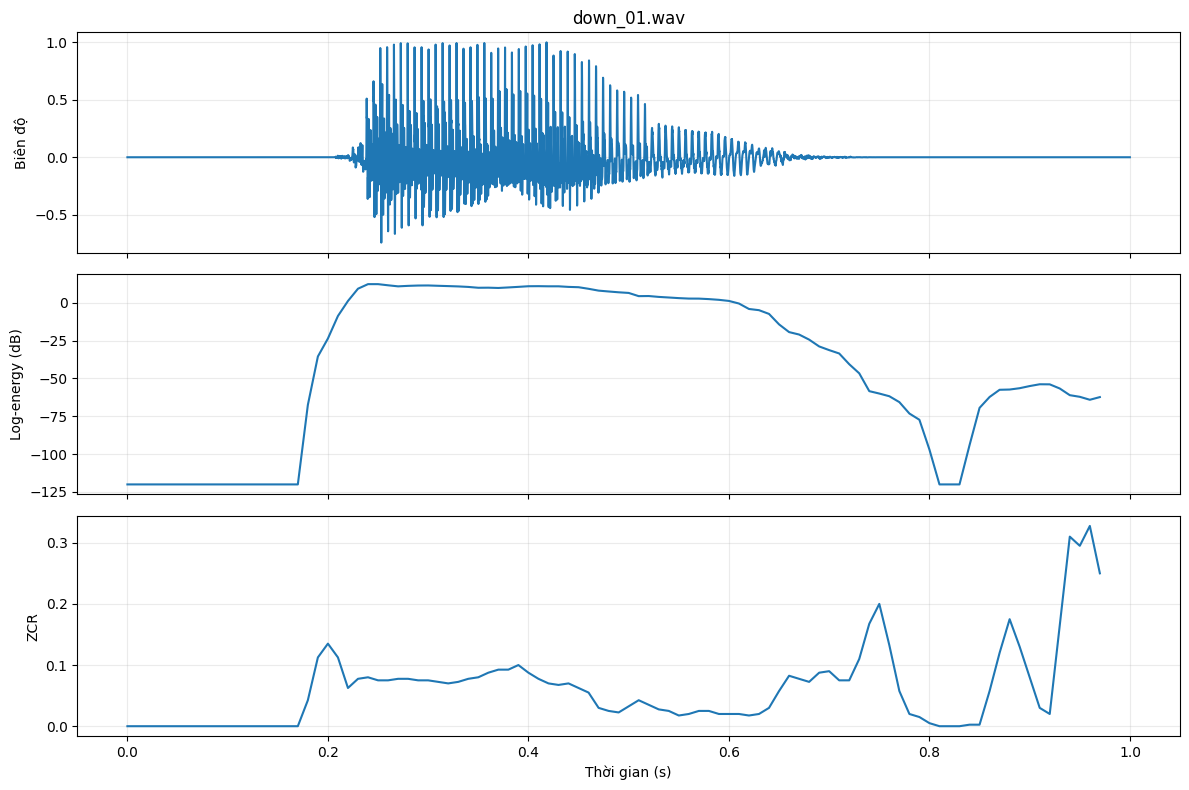

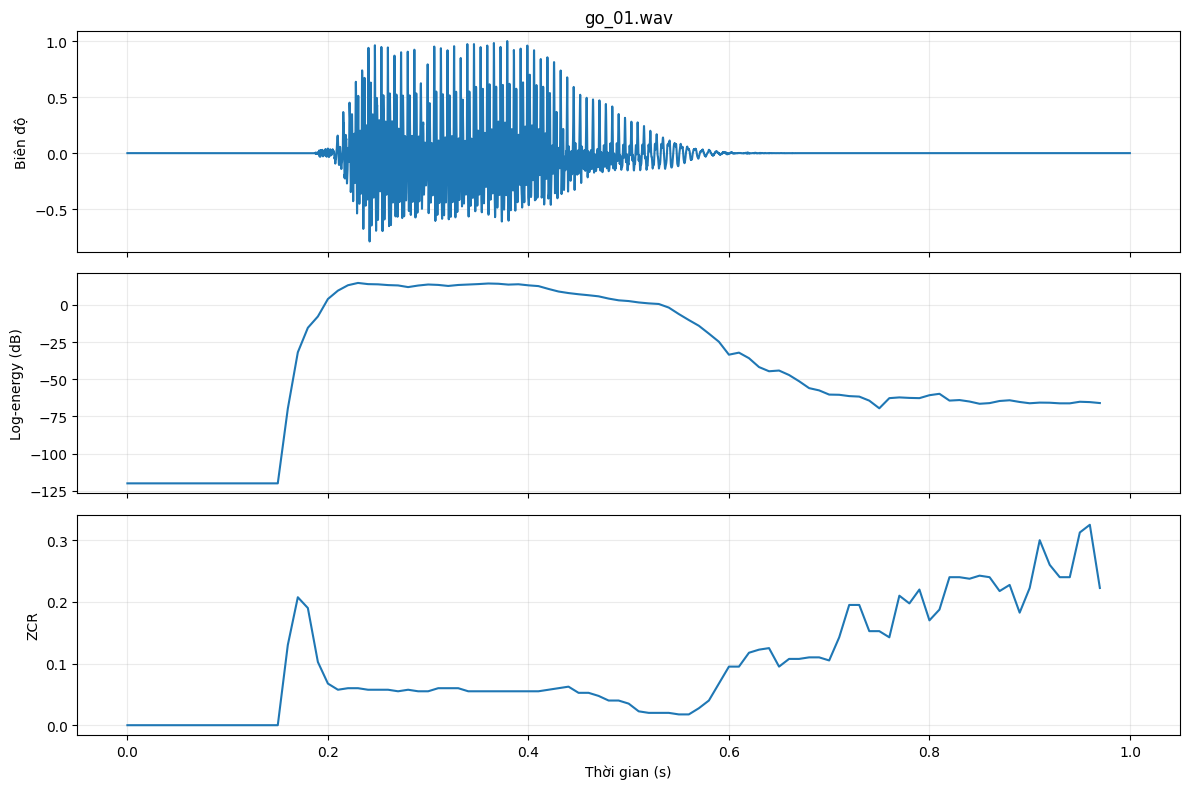

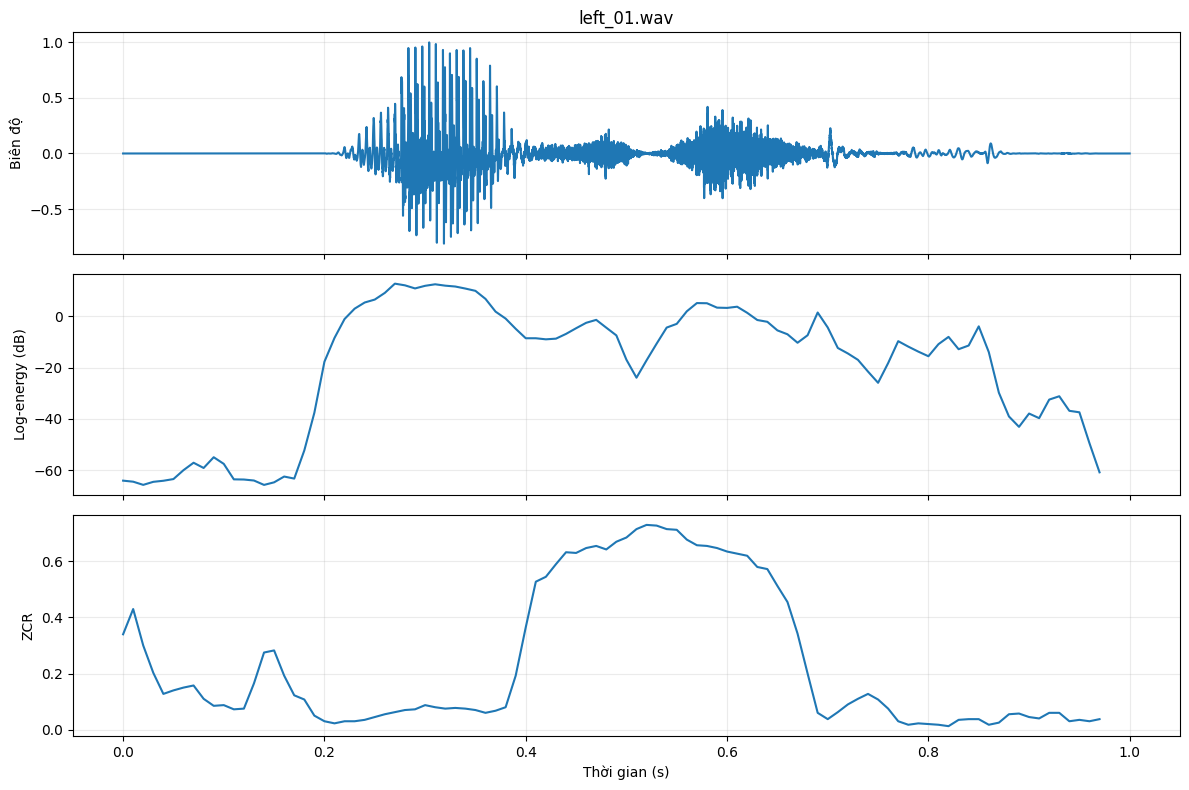

In [7]:
def short_time_features(y):
    frames_raw = frame_signal(y, apply_hamming=False)
    frames_win = frame_signal(y, apply_hamming=True)

    energy = np.sum(frames_win ** 2, axis=1)
    rms = np.sqrt(np.mean(frames_win ** 2, axis=1))

    eps = 1e-12
    log_energy_db = 10 * np.log10(energy + eps)

    signs = np.where(frames_raw >= 0, 1.0, -1.0)
    crossings = np.abs(np.diff(signs, axis=1)) / 2.0
    zcr = np.sum(crossings, axis=1) / frames_raw.shape[1]

    return frames_raw, frames_win, energy, rms, log_energy_db, zcr


def plot_time_features(path, save=True):
    y = load_audio(path)
    _, _, energy, rms, log_energy_db, zcr = short_time_features(y)

    t_wave = np.arange(len(y)) / FS
    t_frame = frame_times(len(energy))

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(t_wave, y)
    axes[0].set_ylabel("Biên độ")
    axes[0].set_title(Path(path).name)
    axes[0].grid(alpha=0.25)

    axes[1].plot(t_frame, log_energy_db)
    axes[1].set_ylabel("Log-energy (dB)")
    axes[1].grid(alpha=0.25)

    axes[2].plot(t_frame, zcr)
    axes[2].set_ylabel("ZCR")
    axes[2].set_xlabel("Thời gian (s)")
    axes[2].grid(alpha=0.25)

    plt.tight_layout()

    if save:
        out = FIG_DIR / f"B_energy_zcr_{Path(path).stem}.png"
        fig.savefig(out, dpi=160, bbox_inches="tight")

    return fig


for f in example_files[:3]:
    plot_time_features(f)
    plt.show()

**Gợi ý nhận xét**:
- Silence: energy/RMS thấp.
- Voiced: energy thường cao, ZCR thường thấp hơn.
- Unvoiced/fricative: energy có thể thấp hơn voiced nhưng ZCR thường cao hơn.

# C. Endpoint detection

Tự xây dựng hàm dựa trên **log-energy tương đối**, sau đó dùng ZCR để tinh chỉnh nhẹ và thêm margin để tránh cắt mất phụ âm đầu/cuối.

Trước trim: 1.000 s
Sau trim : 0.575 s
Start=0.150s, End=0.725s


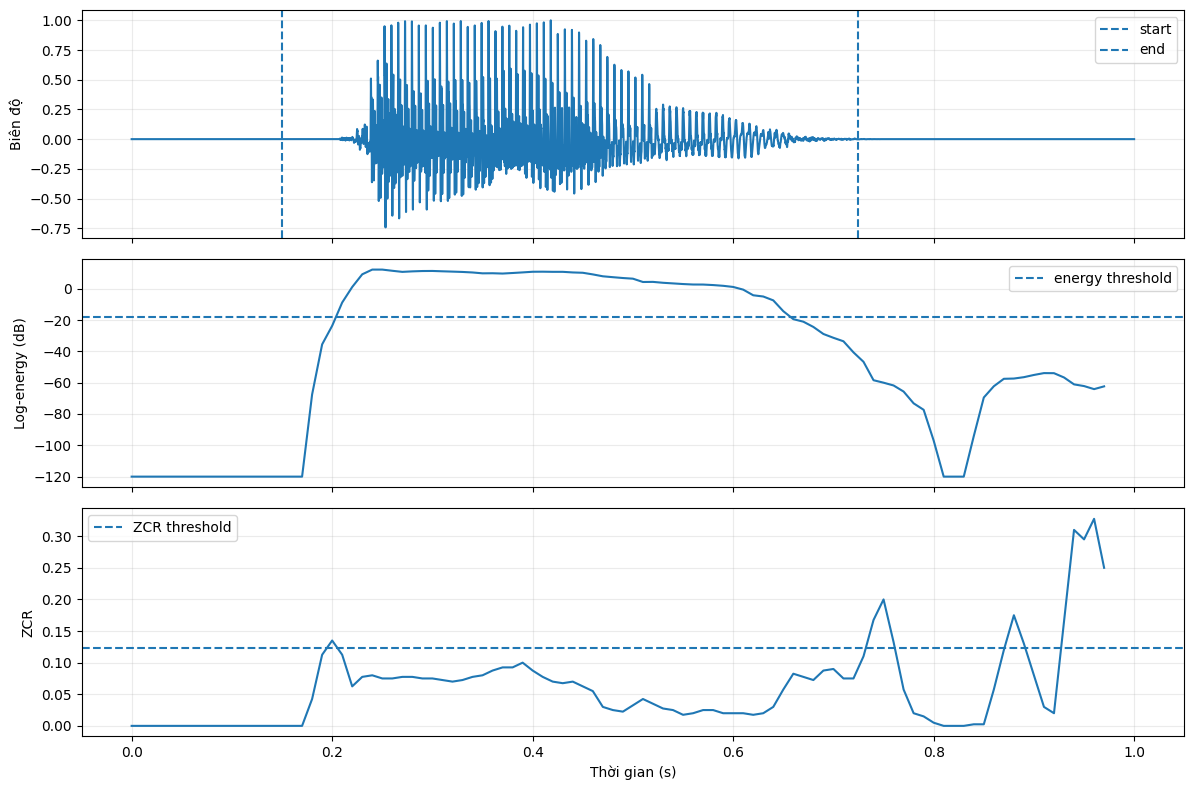

In [8]:
def endpoint_detect(
    y,
    energy_rel_db=30.0,
    margin_ms=50,
    use_zcr_refine=True,
    zcr_ratio=1.5,
    max_refine_frames=4
):
    # 1) Tính log-energy theo frame.
    # 2) Ngưỡng = max(log_energy) - energy_rel_db.
    # 3) Lấy frame đầu/cuối vượt ngưỡng.
    # 4) Có thể mở rộng nhẹ bằng ZCR ở vùng biên.
    # 5) Thêm margin theo ms.

    frames_raw, frames_win, energy, rms, loge, zcr = short_time_features(y)

    if len(loge) == 0:
        return y.copy(), (0, len(y)), {}

    threshold = np.max(loge) - energy_rel_db
    active = np.where(loge >= threshold)[0]

    if len(active) == 0:
        return y.copy(), (0, len(y)), {
            "threshold_db": threshold,
            "log_energy_db": loge,
            "zcr": zcr
        }

    start_f = int(active[0])
    end_f = int(active[-1])

    if use_zcr_refine:
        edge_count = max(1, min(5, len(zcr) // 5))
        noise_zcr = np.median(np.r_[zcr[:edge_count], zcr[-edge_count:]])
        zcr_thr = max(noise_zcr * zcr_ratio, np.percentile(zcr, 60))

        for _ in range(max_refine_frames):
            if start_f > 0 and zcr[start_f - 1] >= zcr_thr:
                start_f -= 1
            else:
                break

        for _ in range(max_refine_frames):
            if end_f < len(zcr) - 1 and zcr[end_f + 1] >= zcr_thr:
                end_f += 1
            else:
                break
    else:
        zcr_thr = None

    start_sample = start_f * HOP
    end_sample = min(len(y), end_f * HOP + WIN)

    margin = int(round(FS * margin_ms / 1000))
    start_sample = max(0, start_sample - margin)
    end_sample = min(len(y), end_sample + margin)

    y_trim = y[start_sample:end_sample]

    debug = {
        "start_frame": start_f,
        "end_frame": end_f,
        "threshold_db": threshold,
        "zcr_threshold": zcr_thr,
        "log_energy_db": loge,
        "zcr": zcr
    }

    return y_trim, (start_sample, end_sample), debug


def plot_endpoint(path, energy_rel_db=30.0, margin_ms=50):
    y = load_audio(path)
    yt, (s, e), dbg = endpoint_detect(
        y,
        energy_rel_db=energy_rel_db,
        margin_ms=margin_ms,
        use_zcr_refine=True
    )

    t = np.arange(len(y)) / FS
    tf = frame_times(len(dbg["log_energy_db"]))

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(t, y)
    axes[0].axvline(s / FS, linestyle="--", label="start")
    axes[0].axvline(e / FS, linestyle="--", label="end")
    axes[0].set_ylabel("Biên độ")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(tf, dbg["log_energy_db"])
    axes[1].axhline(dbg["threshold_db"], linestyle="--", label="energy threshold")
    axes[1].set_ylabel("Log-energy (dB)")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    axes[2].plot(tf, dbg["zcr"])
    if dbg["zcr_threshold"] is not None:
        axes[2].axhline(dbg["zcr_threshold"], linestyle="--", label="ZCR threshold")
    axes[2].set_ylabel("ZCR")
    axes[2].set_xlabel("Thời gian (s)")
    axes[2].legend()
    axes[2].grid(alpha=0.25)

    plt.tight_layout()

    print(f"Trước trim: {len(y)/FS:.3f} s")
    print(f"Sau trim : {len(yt)/FS:.3f} s")
    print(f"Start={s/FS:.3f}s, End={e/FS:.3f}s")

    return fig, yt


if example_files:
    f = example_files[0]
    fig, y_trim_example = plot_endpoint(f, energy_rel_db=30, margin_ms=50)
    fig.savefig(FIG_DIR / f"C_endpoint_{Path(f).stem}.png", dpi=160, bbox_inches="tight")
    plt.show()

In [9]:
import shutil
from pathlib import Path

def trim_and_save_all(
    root=DATASET_ROOT,
    out_root=TRIM_DIR,
    energy_rel_db=30,
    margin_ms=50
):
    # ==================================================
    # XÓA KẾT QUẢ TRIM CŨ
    # ==================================================
    out_root = Path(out_root)

    if out_root.exists():
        print("Đang xóa dữ liệu trimmed cũ...")
        shutil.rmtree(out_root)

    out_root.mkdir(parents=True, exist_ok=True)

    rows = []

    for lab in LABELS:

        out_folder = out_root / lab
        out_folder.mkdir(parents=True, exist_ok=True)

        files = sorted((Path(root) / lab).glob("*.wav"))

        print(f"{lab}: xử lý {len(files)} file")

        for f in files:

            y = load_audio(f)

            yt, (s, e), _ = endpoint_detect(
                y,
                energy_rel_db=energy_rel_db,
                margin_ms=margin_ms
            )

            out_file = out_folder / f.name

            sf.write(
                out_file,
                yt,
                FS
            )

            rows.append({
                "label": lab,
                "file": f.name,
                "before_s": len(y) / FS,
                "after_s": len(yt) / FS,
                "removed_s": (len(y) - len(yt)) / FS
            })

    print("\nHoàn thành!")
    print(f"Đã tạo {len(rows)} file trimmed.")

    return pd.DataFrame(rows)

trim_stats = trim_and_save_all()

display(trim_stats)

Đang xóa dữ liệu trimmed cũ...
down: xử lý 5 file
go: xử lý 5 file
left: xử lý 5 file
right: xử lý 5 file
up: xử lý 5 file

Hoàn thành!
Đã tạo 25 file trimmed.


,label,file,before_s,after_s,removed_s
0,down,down_01.wav,1.0,0.575,0.425
1,down,down_02.wav,1.0,0.880,0.120
2,down,down_03.wav,1.0,0.555,0.445
3,down,down_04.wav,1.0,1.000,0.000
4,down,down_05.wav,1.0,0.635,0.365
5,go,go_01.wav,1.0,0.525,0.475
6,go,go_02.wav,1.0,0.475,0.525
7,go,go_03.wav,1.0,0.525,0.475
8,go,go_04.wav,1.0,1.000,0.000
9,go,go_05.wav,1.0,0.545,0.455


# D. MFCC

Pipeline:
`pre-emphasis → frame/window → FFT/power → Mel filterbank → log → DCT`

Tham số:
- α = 0.97
- Hamming
- n_mels = 24
- n_mfcc = 13
- n_fft = 512
- center = False
- CMN theo từng utterance

In [10]:
def pre_emphasis(y, alpha=PRE_EMPH):
    return lfilter([1.0, -alpha], [1.0], y)


def mfcc_feature(y, n_mfcc=N_MFCC, add_delta=False, cmn=True):
    y2 = pre_emphasis(y, PRE_EMPH)

    M = librosa.feature.mfcc(
        y=y2,
        sr=FS,
        n_mfcc=n_mfcc,
        n_mels=N_MELS,
        n_fft=NFFT,
        win_length=WIN,
        hop_length=HOP,
        window="hamming",
        center=False
    )

    if cmn:
        M = M - np.mean(M, axis=1, keepdims=True)

    if add_delta:
        delta = librosa.feature.delta(M)
        M = np.vstack([M, delta])

    return M.T


def extract_feature_from_file(path, trim=True, add_delta=False):
    y = load_audio(path)

    if trim:
        y, _, _ = endpoint_detect(y)

    return mfcc_feature(y, add_delta=add_delta)

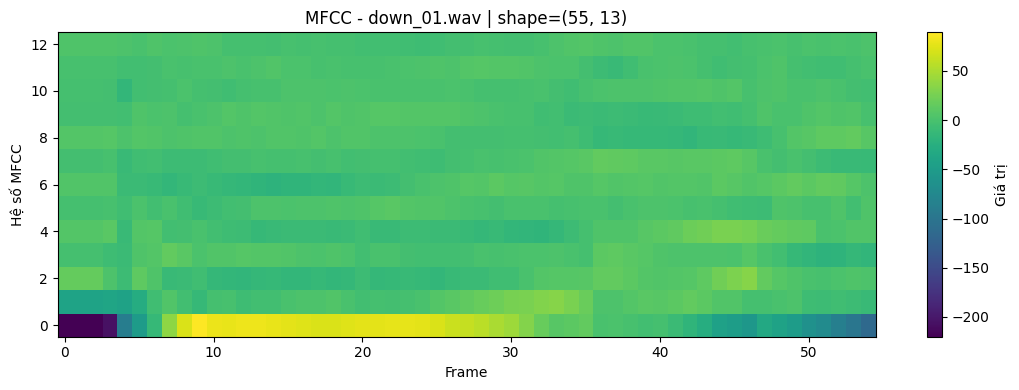

down_01.wav -> MFCC shape: (55, 13)


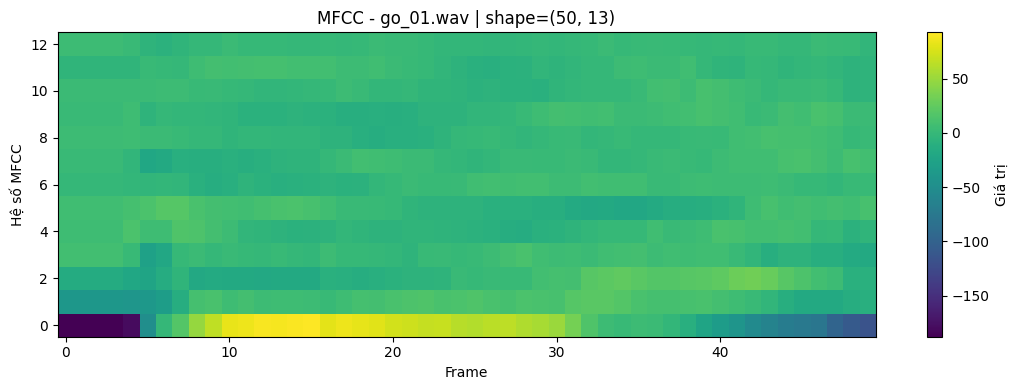

go_01.wav -> MFCC shape: (50, 13)


In [11]:
def plot_mfcc(path, trim=True, add_delta=False):
    y = load_audio(path)
    if trim:
        y, _, _ = endpoint_detect(y)

    M = mfcc_feature(y, add_delta=add_delta)

    fig, ax = plt.subplots(figsize=(11, 4))
    im = ax.imshow(M.T, aspect="auto", origin="lower", interpolation="nearest")
    ax.set_title(f"MFCC - {Path(path).name} | shape={M.shape}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Hệ số MFCC" if not add_delta else "MFCC + Δ")
    fig.colorbar(im, ax=ax, label="Giá trị")
    plt.tight_layout()

    return fig, M


mfcc_examples = []
for f in example_files[:2]:
    fig, M = plot_mfcc(f)
    mfcc_examples.append(M)
    fig.savefig(FIG_DIR / f"D_mfcc_{Path(f).stem}.png", dpi=160, bbox_inches="tight")
    plt.show()
    print(Path(f).name, "-> MFCC shape:", M.shape)

**Nhận xét:** mỗi file có thể có số frame `T` khác nhau vì thời lượng phát âm khác nhau, nhưng số chiều feature/frame luôn cố định: **13** với MFCC, hoặc **26** khi ghép thêm Δ.

# E. DTW — tự cài đặt

- Local distance Euclidean
- Ba bước: trên, trái, chéo
- Backtracking optimal path
- Chuẩn hóa `cost / path_length`

In [12]:
def euclidean_distance(a, b):
    return float(np.sqrt(np.sum((a - b) ** 2)))


def local_distance_matrix(X, Y):
    N, M = len(X), len(Y)
    C = np.zeros((N, M), dtype=np.float64)

    for i in range(N):
        for j in range(M):
            C[i, j] = euclidean_distance(X[i], Y[j])

    return C


def dtw_distance(X, Y):
    N, M = len(X), len(Y)
    C = local_distance_matrix(X, Y)

    D = np.full((N + 1, M + 1), np.inf, dtype=np.float64)
    D[0, 0] = 0.0

    back = np.full((N + 1, M + 1, 2), -1, dtype=int)

    for i in range(1, N + 1):
        for j in range(1, M + 1):
            candidates = [
                (D[i - 1, j],     i - 1, j),
                (D[i, j - 1],     i,     j - 1),
                (D[i - 1, j - 1], i - 1, j - 1)
            ]

            best_cost, pi, pj = min(candidates, key=lambda z: z[0])
            D[i, j] = C[i - 1, j - 1] + best_cost
            back[i, j] = (pi, pj)

    path = []
    i, j = N, M

    while i > 0 or j > 0:
        path.append((i - 1, j - 1))
        pi, pj = back[i, j]

        if pi < 0 or pj < 0:
            break

        i, j = pi, pj

    path.reverse()
    norm_cost = D[N, M] / max(len(path), 1)

    return norm_cost, path, D[1:, 1:], C

In [13]:
if mfcc_examples:
    test_cost, test_path, _, _ = dtw_distance(mfcc_examples[0], mfcc_examples[0])
    print("DTW_norm(X, X) =", test_cost)

DTW_norm(X, X) = 0.0


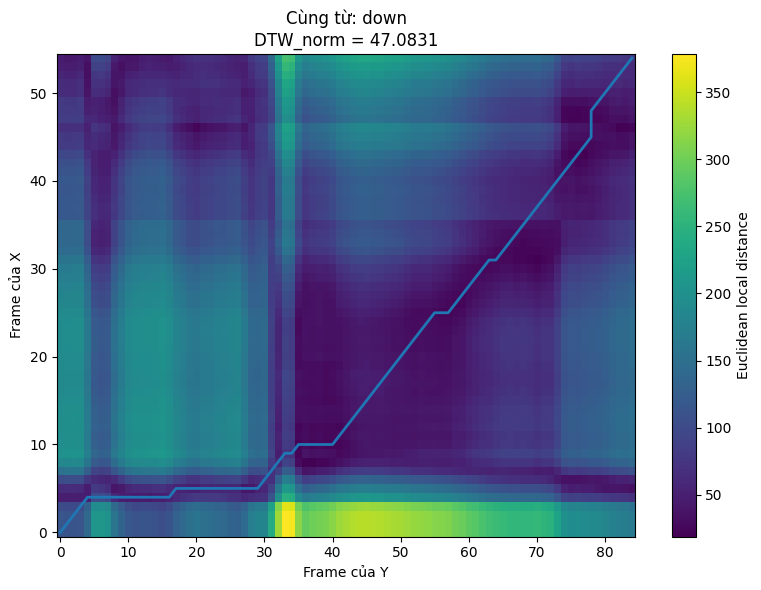

DTW cùng từ: 47.08313543854986


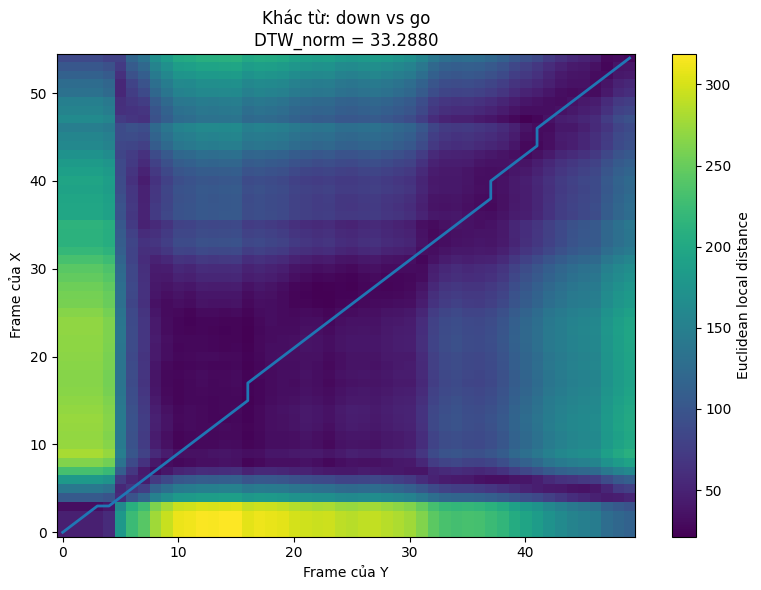

DTW khác từ: 33.288016432791665


In [14]:
def plot_dtw(X, Y, title="DTW"):
    cost, path, Dacc, C = dtw_distance(X, Y)
    path_arr = np.array(path)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(C, origin="lower", aspect="auto", interpolation="nearest")

    if len(path_arr):
        ax.plot(path_arr[:, 1], path_arr[:, 0], linewidth=2)

    ax.set_xlabel("Frame của Y")
    ax.set_ylabel("Frame của X")
    ax.set_title(f"{title}\nDTW_norm = {cost:.4f}")
    fig.colorbar(im, ax=ax, label="Euclidean local distance")
    plt.tight_layout()

    return fig, cost, path


def pick_two_files_same_word(label):
    fs = sorted((DATASET_ROOT / label).glob("*.wav"))
    return fs[:2] if len(fs) >= 2 else []


same = pick_two_files_same_word(LABELS[0])
if len(same) == 2:
    X1 = extract_feature_from_file(same[0], trim=True)
    X2 = extract_feature_from_file(same[1], trim=True)

    fig, cost_same, _ = plot_dtw(X1, X2, f"Cùng từ: {LABELS[0]}")
    fig.savefig(FIG_DIR / "E_dtw_same_word.png", dpi=160, bbox_inches="tight")
    plt.show()
    print("DTW cùng từ:", cost_same)

f_a = sorted((DATASET_ROOT / LABELS[0]).glob("*.wav"))
f_b = sorted((DATASET_ROOT / LABELS[1]).glob("*.wav"))

if f_a and f_b:
    XA = extract_feature_from_file(f_a[0], trim=True)
    XB = extract_feature_from_file(f_b[0], trim=True)

    fig, cost_diff, _ = plot_dtw(XA, XB, f"Khác từ: {LABELS[0]} vs {LABELS[1]}")
    fig.savefig(FIG_DIR / "E_dtw_different_words.png", dpi=160, bbox_inches="tight")
    plt.show()
    print("DTW khác từ:", cost_diff)

# F. Bộ nhận dạng nearest-template

Mỗi file test:
`feature → DTW tới toàn bộ templates → lấy khoảng cách tốt nhất mỗi lớp → chọn lớp nhỏ nhất`

In [15]:
def build_templates(
    train_files=TRAIN_FILES,
    trim=True,
    add_delta=False
):
    templates = {lab: [] for lab in LABELS}

    for lab in LABELS:
        for f in train_files[lab]:
            X = extract_feature_from_file(
                f,
                trim=trim,
                add_delta=add_delta
            )
            templates[lab].append({
                "file": f,
                "feature": X
            })

    return templates


def recognize(
    path,
    templates,
    trim=True,
    add_delta=False,
    reject_threshold=None
):
    X = extract_feature_from_file(
        path,
        trim=trim,
        add_delta=add_delta
    )

    scores = {}

    for lab, refs in templates.items():
        if not refs:
            scores[lab] = np.inf
            continue

        distances = [
            dtw_distance(X, item["feature"])[0]
            for item in refs
        ]
        scores[lab] = min(distances)

    ranking = sorted(scores.items(), key=lambda kv: kv[1])
    pred = ranking[0][0]

    if reject_threshold is not None and ranking[0][1] > reject_threshold:
        pred = "unknown"

    return pred, ranking

In [16]:
templates = build_templates(trim=True, add_delta=False)

shown = 0

for true_lab in LABELS:
    for f in TEST_FILES[true_lab]:
        pred, ranking = recognize(
            f,
            templates,
            trim=True,
            add_delta=False
        )

        print(
            f"{f.name:20s} | true={true_lab:6s} | pred={pred:6s} | "
            f"top-3={[(lab, round(score, 4)) for lab, score in ranking[:3]]}"
        )

        shown += 1
        if shown >= 5:
            break

    if shown >= 5:
        break

down_04.wav          | true=down   | pred=up     | top-3=[('up', np.float64(50.7671)), ('down', np.float64(56.5251)), ('left', np.float64(57.9671))]
down_05.wav          | true=down   | pred=down   | top-3=[('down', np.float64(37.3522)), ('go', np.float64(42.3534)), ('up', np.float64(49.0793))]
go_04.wav            | true=go     | pred=go     | top-3=[('go', np.float64(48.5997)), ('up', np.float64(53.3845)), ('down', np.float64(55.9439))]
go_05.wav            | true=go     | pred=go     | top-3=[('go', np.float64(38.6508)), ('down', np.float64(45.3828)), ('up', np.float64(52.329))]
left_04.wav          | true=left   | pred=up     | top-3=[('up', np.float64(47.3178)), ('go', np.float64(53.0652)), ('left', np.float64(54.4686))]


# G. Đánh giá và thí nghiệm

Bắt buộc:
- Accuracy
- Confusion matrix
- E1: có endpoint detection vs không endpoint detection
- E2: MFCC 13 hệ số vs MFCC + Δ

In [17]:
def evaluate_system(
    train_files=TRAIN_FILES,
    test_files=TEST_FILES,
    trim=True,
    add_delta=False,
    verbose=True
):
    templates = build_templates(
        train_files=train_files,
        trim=trim,
        add_delta=add_delta
    )

    y_true = []
    y_pred = []
    rows = []

    for true_lab in LABELS:
        for f in test_files[true_lab]:
            pred, ranking = recognize(
                f,
                templates,
                trim=trim,
                add_delta=add_delta
            )

            y_true.append(true_lab)
            y_pred.append(pred)

            rows.append({
                "file": str(f),
                "true_label": true_lab,
                "pred_label": pred,
                "top1_label": ranking[0][0],
                "top1_score": ranking[0][1],
                "top2_label": ranking[1][0] if len(ranking) > 1 else None,
                "top2_score": ranking[1][1] if len(ranking) > 1 else None
            })

            if verbose:
                print(
                    f"{f.name:20s} -> {pred:6s} | "
                    f"top-3={[(lab, round(score, 4)) for lab, score in ranking[:3]]}"
                )

    acc = accuracy_score(y_true, y_pred) if y_true else np.nan
    cm = confusion_matrix(y_true, y_pred, labels=LABELS) if y_true else np.zeros((len(LABELS), len(LABELS)), dtype=int)

    return acc, cm, pd.DataFrame(rows), y_true, y_pred


acc, cm, results_df, y_true, y_pred = evaluate_system(
    trim=True,
    add_delta=False,
    verbose=True
)

print(f"\nAccuracy = {acc*100:.2f}%")
display(results_df)

down_04.wav          -> up     | top-3=[('up', np.float64(50.7671)), ('down', np.float64(56.5251)), ('left', np.float64(57.9671))]
down_05.wav          -> down   | top-3=[('down', np.float64(37.3522)), ('go', np.float64(42.3534)), ('up', np.float64(49.0793))]
go_04.wav            -> go     | top-3=[('go', np.float64(48.5997)), ('up', np.float64(53.3845)), ('down', np.float64(55.9439))]
go_05.wav            -> go     | top-3=[('go', np.float64(38.6508)), ('down', np.float64(45.3828)), ('up', np.float64(52.329))]
left_04.wav          -> up     | top-3=[('up', np.float64(47.3178)), ('go', np.float64(53.0652)), ('left', np.float64(54.4686))]
left_05.wav          -> right  | top-3=[('right', np.float64(44.4478)), ('left', np.float64(49.5312)), ('up', np.float64(50.6066))]
right_04.wav         -> up     | top-3=[('up', np.float64(54.593)), ('left', np.float64(57.5244)), ('right', np.float64(58.8616))]
right_05.wav         -> right  | top-3=[('right', np.float64(41.2456)), ('up', np.float64(5

,file,true_label,pred_label,top1_label,top1_score,top2_label,top2_score
0,data\down\down_04.wav,down,up,up,50.767082,down,56.525100
1,data\down\down_05.wav,down,down,down,37.352164,go,42.353390
2,data\go\go_04.wav,go,go,go,48.599689,up,53.384534
3,data\go\go_05.wav,go,go,go,38.650779,down,45.382781
4,data\left\left_04.wav,left,up,up,47.317754,go,53.065229
5,data\left\left_05.wav,left,right,right,44.447849,left,49.531199
6,data\right\right_04.wav,right,up,up,54.592985,left,57.524380
7,data\right\right_05.wav,right,right,right,41.245618,up,50.266303
8,data\up\up_04.wav,up,up,up,42.813891,right,44.073197
9,data\up\up_05.wav,up,go,go,33.179857,down,36.120401


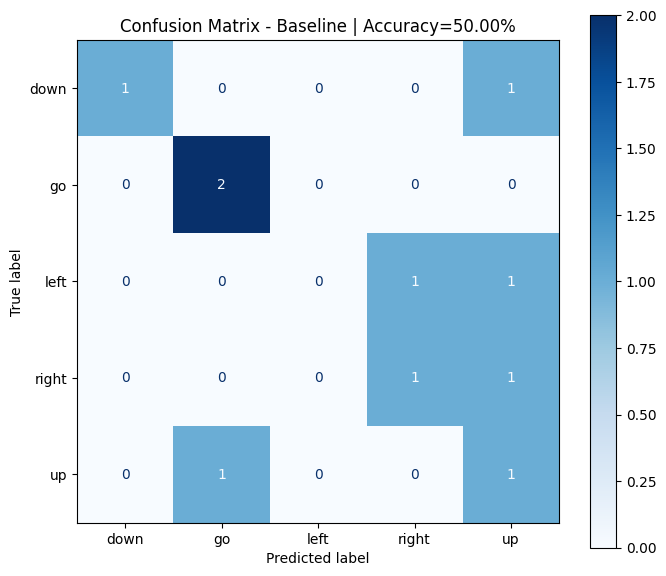

In [18]:
def plot_confusion(cm, title, filename=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[DISPLAY_LABELS[x] for x in LABELS]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
    ax.set_title(title)
    plt.tight_layout()

    if filename:
        fig.savefig(FIG_DIR / filename, dpi=160, bbox_inches="tight")

    return fig


plot_confusion(cm, f"Confusion Matrix - Baseline | Accuracy={acc*100:.2f}%", "G_confusion_baseline.png")
plt.show()

In [19]:
results_path = RESULT_DIR / "results.csv"
results_df.to_csv(results_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu {results_path}")

Đã lưu results\results.csv


## Thí nghiệm E1 — Có endpoint detection vs không endpoint detection

In [20]:
exp_e1 = []

for trim_flag in [False, True]:
    acc_e1, cm_e1, df_e1, _, _ = evaluate_system(
        trim=trim_flag,
        add_delta=False,
        verbose=False
    )

    exp_e1.append({
        "experiment": "E1",
        "trim": trim_flag,
        "feature": "MFCC13",
        "accuracy": acc_e1
    })

    print(f"trim={trim_flag}: accuracy={acc_e1*100:.2f}%")

e1_df = pd.DataFrame(exp_e1)
display(e1_df)

trim=False: accuracy=60.00%
trim=True: accuracy=50.00%


,experiment,trim,feature,accuracy
0,E1,False,MFCC13,0.6
1,E1,True,MFCC13,0.5


## Thí nghiệm E2 — MFCC 13 vs MFCC + Δ

In [21]:
exp_e2 = []

for add_delta in [False, True]:
    acc_e2, cm_e2, df_e2, _, _ = evaluate_system(
        trim=True,
        add_delta=add_delta,
        verbose=False
    )

    exp_e2.append({
        "experiment": "E2",
        "trim": True,
        "feature": "MFCC13+Delta" if add_delta else "MFCC13",
        "accuracy": acc_e2
    })

    print(
        f"feature={'MFCC13+Delta' if add_delta else 'MFCC13'}: "
        f"accuracy={acc_e2*100:.2f}%"
    )

e2_df = pd.DataFrame(exp_e2)
display(e2_df)

feature=MFCC13: accuracy=50.00%
feature=MFCC13+Delta: accuracy=40.00%


,experiment,trim,feature,accuracy
0,E2,True,MFCC13,0.5
1,E2,True,MFCC13+Delta,0.4


## Tổng hợp E1–E2

In [22]:
experiments_df = pd.concat([e1_df, e2_df], ignore_index=True)
experiments_df.to_csv(RESULT_DIR / "experiments_E1_E2.csv", index=False, encoding="utf-8-sig")
display(experiments_df)

,experiment,trim,feature,accuracy
0,E1,False,MFCC13,0.6
1,E1,True,MFCC13,0.5
2,E2,True,MFCC13,0.5
3,E2,True,MFCC13+Delta,0.4


## Phân tích cặp từ dễ nhầm nhất

Tìm ô ngoài đường chéo có số lần nhầm lớn nhất.

In [23]:
def most_confused_pair(cm, labels=LABELS):
    cm2 = cm.copy().astype(float)
    np.fill_diagonal(cm2, -np.inf)

    if np.all(np.isneginf(cm2)):
        return None

    i, j = np.unravel_index(np.argmax(cm2), cm2.shape)
    count = cm[i, j]

    if count <= 0:
        return None

    return labels[i], labels[j], int(count)


pair = most_confused_pair(cm)

if pair is None:
    print("Không có lỗi nhầm trong confusion matrix hiện tại.")
else:
    print(f"Cặp dễ nhầm nhất: true={pair[0]} -> predicted={pair[1]} ({pair[2]} lần)")

Cặp dễ nhầm nhất: true=down -> predicted=up (1 lần)


# Gợi ý phần nhận xét báo cáo

Sau khi chạy notebook bằng dữ liệu của bạn, hãy nhận xét dựa trên **số liệu thực tế**:

1. **Energy + ZCR**: silence có energy thấp; voiced thường energy cao và ZCR thấp; unvoiced/fricative thường ZCR cao hơn.
2. **Endpoint**: so sánh thời lượng trước/sau trim; nghe lại file trong `trimmed/`; nếu cắt mất âm thì tăng `margin_ms` hoặc điều chỉnh `energy_rel_db`.
3. **MFCC**: số frame có thể khác nhau nhưng số chiều feature/frame cố định.
4. **DTW**: cùng từ thường có `DTW_norm` thấp hơn khác từ; đoạn ngang/dọc của path thể hiện kéo giãn/nén thời gian.
5. **Recognizer**: báo cáo accuracy và cặp từ dễ nhầm nhất từ confusion matrix.
6. **E1**: so sánh accuracy có/không endpoint detection.
7. **E2**: so sánh MFCC13 với MFCC13+Δ.

# Checklist sản phẩm nộp

Cấu trúc thư mục đề xuất:

```text
thu_muc_lab2/
├── Lab2_2351260688_NguyenNgocTien.ipynb
├── data/
│   ├── down/      # 5 WAV
│   ├── go/        # 5 WAV
│   ├── left/      # 5 WAV
│   ├── right/     # 5 WAV
│   └── up/        # 5 WAV
├── figures/
├── results/
│   ├── results.csv
│   └── experiments_E1_E2.csv
├── report/
│   └── Lab2_Report.pdf
└── trimmed/       # sinh tự động, không cần push GitHub
```

Chạy notebook từ trên xuống dưới. Các file trong `figures/`, `trimmed/` và `results/` sẽ được tạo/cập nhật trong quá trình chạy.